### Librerias

In [1]:
#Importar las librerías necesarias para la adquisición y manipulación de datos.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Configuración de Entorno Visual y Carga de DataSets

In [49]:
# Configuración estética profesional para los gráficos
sns.set_theme(style="whitegrid", context="talk")
colores_mfc = ['#1B4965', '#62B6CB', '#CAE9FF', '#FFC300'] # Paleta personalizada (Azules y acento)

# Carga de los datasets
df_tabla_general_goleadores = pd.read_csv("../datos/processed/TablaGeneral_Goleadores_TA25_GrupoB.csv")
df_goleadores_detallado = pd.read_csv("../datos/processed/Goleadores_TA25_GrupoB_clean.csv")
df_resultados = pd.read_csv("../datos/processed/Resultados_TA25_GrupoB_clean.csv")

# Exploración inicial de los datos
print("\nFilas del dataset TABLA DE GOLEADORES SUB-15 GENERAL - TORNEO APERTURA 2025 - GRUPO B:") 
print(df_tabla_general_goleadores.shape[0])

print("\nFilas del dataset TABLA DE GOLEADORES SUB-15 DETALLADA - TORNEO APERTURA 2025 - GRUPO B:") 
print(df_goleadores_detallado.shape[0])

print("\nFilas del dataset de RESULTADOS - LIGA PROMESAS - SUB15 - TORNEO APERTURA 2025 - GRUPO B:")
print(df_resultados.shape[0])

print("\nPrimeras filas del dataset:")
df_resultados


Filas del dataset TABLA DE GOLEADORES SUB-15 GENERAL - TORNEO APERTURA 2025 - GRUPO B:
40

Filas del dataset TABLA DE GOLEADORES SUB-15 DETALLADA - TORNEO APERTURA 2025 - GRUPO B:
23

Filas del dataset de RESULTADOS - LIGA PROMESAS - SUB15 - TORNEO APERTURA 2025 - GRUPO B:
42

Primeras filas del dataset:


,Jornada,Fecha/hora,Estadio,Partido,Resultado,Estado
0,1,2025-04-12 09:30:00,LICEO LOS OLIVOS,ACADEMIA M.F.C - CORE SPORT,0:4,JUGADO
1,1,2025-04-10 15:30:00,DESCONOCIDO,ACADEMIA DEPORTIVA EMANUEL - ESCUELA DE FUTBOL...,3:3,JUGADO
2,1,2025-04-11 16:00:00,''LOS OLIVOS'' PTO. ORDAZ,LOS OLIVOS - ACADEMIA SUR AEROPUERTO FC,0:5,JUGADO
3,2,2025-03-21 15:00:00,CANCHA VILLA BETANIA,S LUGO FC - ACADEMIA M.F.C,1:2,JUGADO
4,2,2025-03-22 14:00:00,CANCHA EL CAMPITO-CORE 8,CORE SPORT - ACADEMIA DEPORTIVA EMANUEL,3:0*,JUGADO
5,2,2025-03-21 15:45:00,"""CIUDAD MINEROS"" PTO. ORDAZ",ESCUELA DE FUTBOL MGD - LOS OLIVOS,3:0*,JUGADO
6,3,2025-03-25 16:30:00,LICEO LOS OLIVOS,ACADEMIA M.F.C - ACADEMIA DEPORTIVA EMANUEL,4:2,JUGADO
7,3,2025-03-22 10:00:00,CANCHA UNION UNARE,ACADEMIA SUR AEROPUERTO FC - ESCUELA DE FUTBOL...,1:0,JUGADO
8,3,2025-03-23 09:00:00,CANCHA EL CAMPITO-CORE 8,CORE SPORT - S LUGO FC,4:3,JUGADO
9,4,2025-03-29 14:30:00,CANCHA UNION UNARE,ACADEMIA SUR AEROPUERTO FC - ACADEMIA M.F.C,3:0,JUGADO


#### 1. Distribución de Variables: Minutos de Anotación (Física y Concentración)

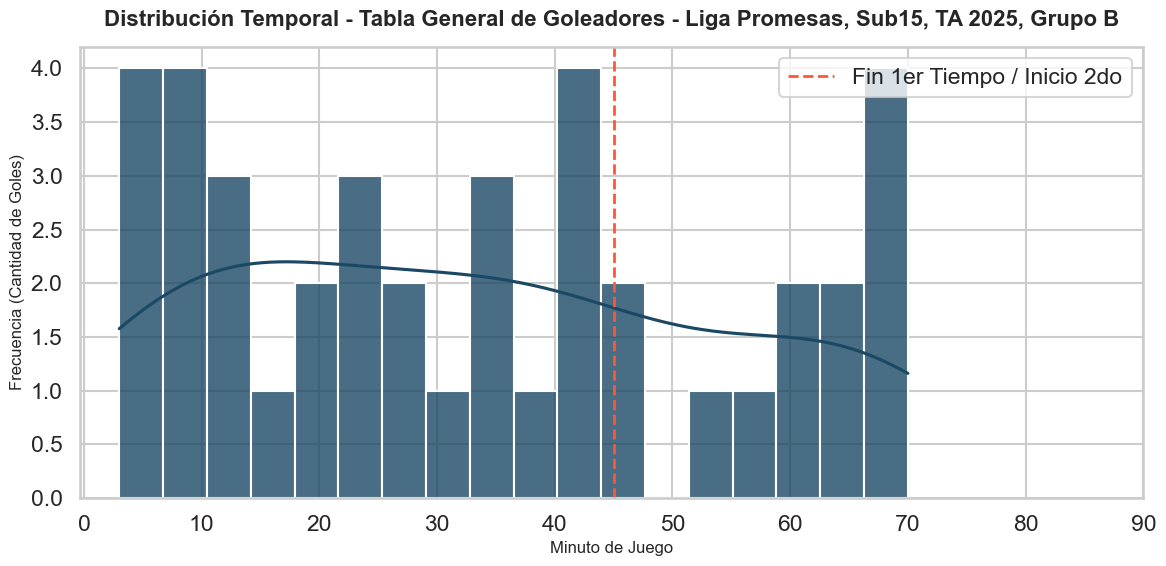

In [41]:
plt.figure(figsize=(12, 6))

# Histograma con curva de densidad (KDE) para ver la tendencia de los minutos
ax1 = sns.histplot(
    data=df_tabla_general_goleadores, 
    x='minuto', 
    bins=18,  # Agrupado aproximadamente cada 5 minutos (asumiendo los 90 min de un partido))
    kde=True, 
    color='#1B4965', 
    edgecolor='white',
    alpha=0.8
)

# Líneas divisorias para los tiempos (Asumiendo formato estándar, ajustar si en Sub-15 juegan menos minutos)
plt.axvline(x=45, color='#FF5733', linestyle='--', linewidth=2, label='Fin 1er Tiempo / Inicio 2do')

plt.title('Distribución Temporal - Tabla General de Goleadores - Liga Promesas, Sub15, TA 2025, Grupo B', fontsize=16, weight='bold', pad=15)
plt.xlabel('Minuto de Juego', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Goles)', fontsize=12)
plt.xticks(np.arange(0, 91, 10)) # Marcas cada 10 minutos
plt.legend()
plt.tight_layout()
plt.show()

### 2. Comparación entre Grupos: Rendimiento Ofensivo según Localía

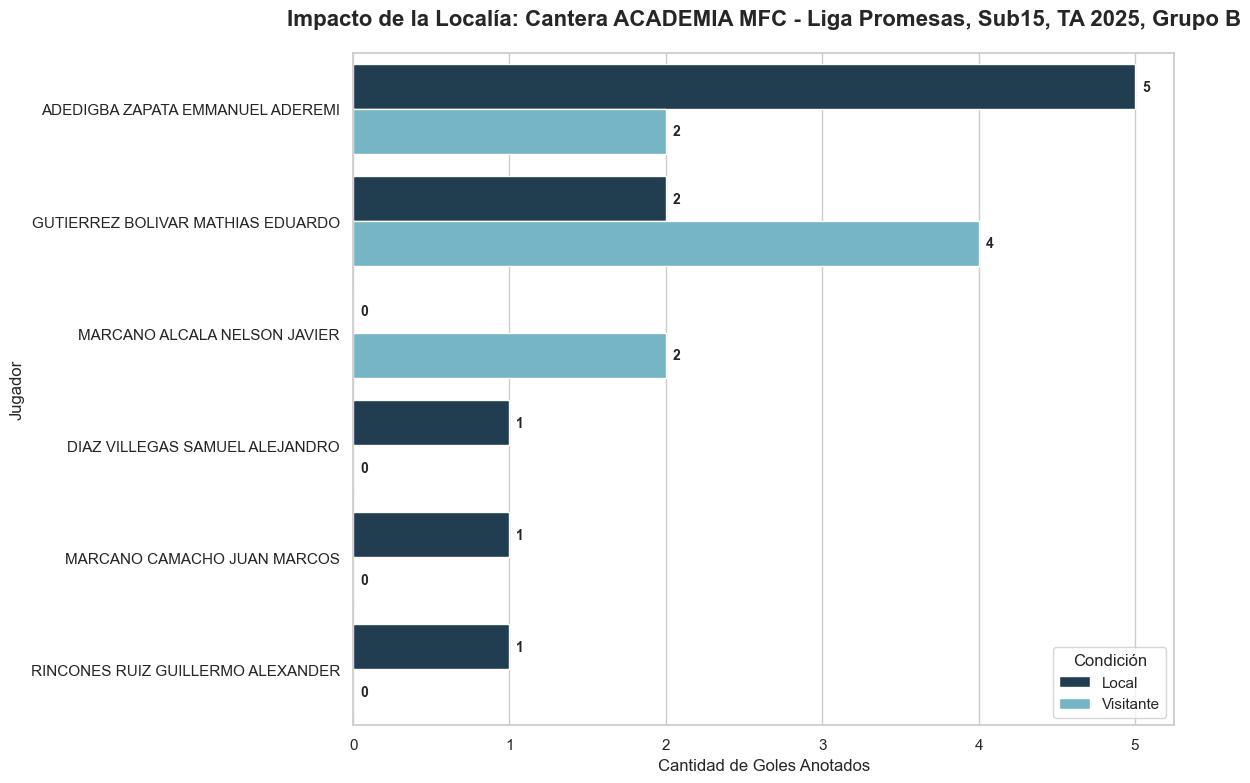

In [47]:
# 1. Configuración de estilo y paleta institucional
sns.set_theme(style="whitegrid")
paleta_escenario = {'Local': '#184058', 'Visitante': '#67BDD3'}

# 2. FILTRAR POR ACADEMIA MFC Y SELECCIONAR TOP
# Filtramos primero para que solo aparezcan tus jugadores
df_mfc_solo = df_goleadores_detallado[
    df_goleadores_detallado['equipo'].str.contains('ACADEMIA M.F.C', case=False, na=False)
].copy()

# Opcional: Si tienes muchos goleadores, puedes limitar al Top 10 del club
df_top_mfc = df_mfc_solo.head(10)

# 3. Transformar (Melt) y RENOMBRAR las categorías
df_plot = df_top_mfc.melt(
    id_vars=['jugador'], 
    value_vars=['goles_local', 'goles_visitante'],
    var_name='escenario', 
    value_name='cantidad'
)

# Mapeamos los nombres técnicos a nombres de presentación
df_plot['escenario'] = df_plot['escenario'].map({
    'goles_local': 'Local', 
    'goles_visitante': 'Visitante'
})

# 4. Crear la visualización
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=df_plot,
    y='jugador',
    x='cantidad',
    hue='escenario',
    palette=paleta_escenario,
    edgecolor='white'
)

# 5. Personalización final con enfoque institucional
plt.title('Impacto de la Localía: Cantera ACADEMIA MFC - Liga Promesas, Sub15, TA 2025, Grupo B', fontsize=16, weight='bold', pad=20)
plt.xlabel('Cantidad de Goles Anotados', fontsize=12)
plt.ylabel('Jugador', fontsize=12)

# La leyenda se genera automáticamente con los colores correctos
plt.legend(title='Condición', loc='lower right')

# Añadir etiquetas de valor en las barras
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

#### 3. Relaciones entre Variables: Eficiencia Neta (Scatter Plot)

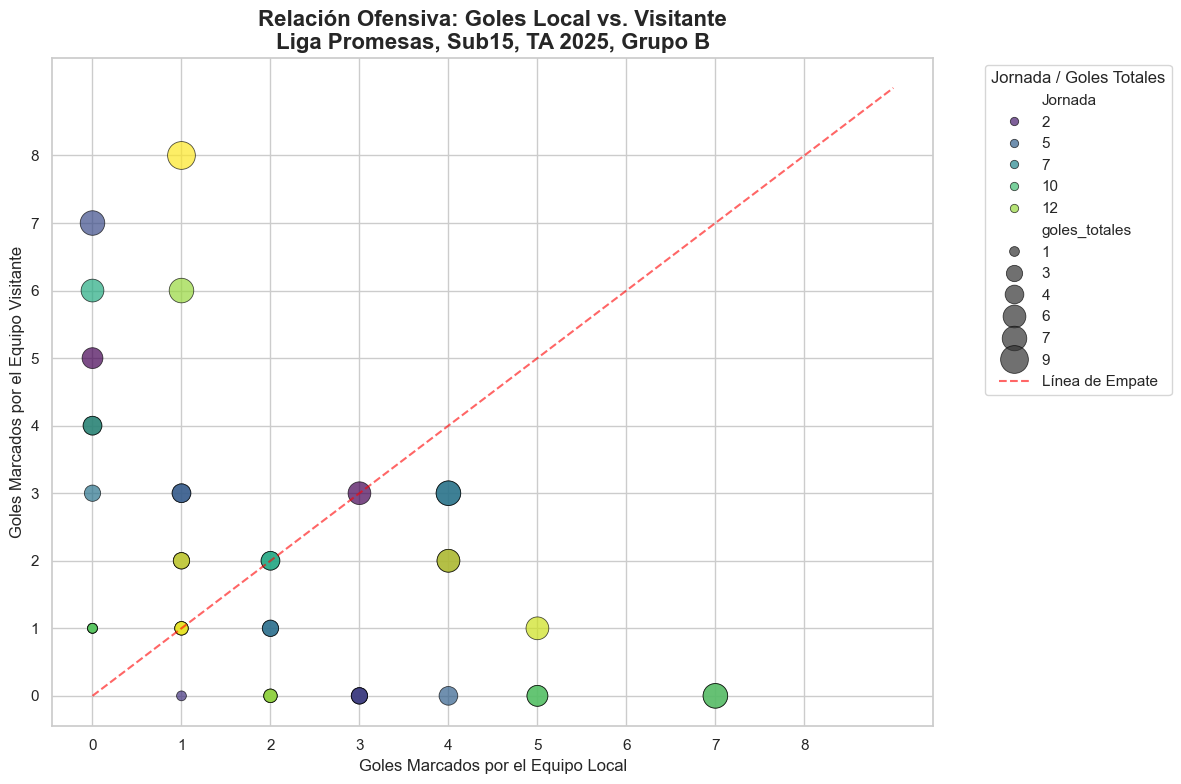

In [51]:
# Función para extraer goles del string "Resultado" (ej: "2:1")
def extraer_goles(resultado, pos):
    try:
        # Limpiamos caracteres especiales como '*' que indica un resultado por incomparecencia
        res_limpio = resultado.replace('*', '').split(':')
        return int(res_limpio[pos])
    except:
        return np.nan

df_resultados['goles_local'] = df_resultados['Resultado'].apply(lambda x: extraer_goles(x, 0))
df_resultados['goles_visitante'] = df_resultados['Resultado'].apply(lambda x: extraer_goles(x, 1))
df_resultados['goles_totales'] = df_resultados['goles_local'] + df_resultados['goles_visitante']

# Eliminamos filas sin resultado válido si las hubiera
df_res = df_resultados.dropna(subset=['goles_local', 'goles_visitante'])

# 2. Configuración Visual
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Usamos 'regplot' o 'scatterplot' con un poco de 'jitter' (ruido visual) 
# porque los goles son números enteros y los puntos se solaparían.
ax = sns.scatterplot(
    data=df_res,
    x='goles_local',
    y='goles_visitante',
    hue='Jornada',
    size='goles_totales',
    sizes=(50, 400),
    palette='viridis',
    alpha=0.7,
    edgecolor='black'
)

# 3. Línea de Igualdad (x=y) para identificar empates y tendencias
limite = int(max(df_res['goles_local'].max(), df_res['goles_visitante'].max()) + 1)
plt.plot([0, limite], [0, limite], color='red', linestyle='--', alpha=0.6, label='Línea de Empate')

# 4. Detalles del Gráfico
plt.title('Relación Ofensiva: Goles Local vs. Visitante\nLiga Promesas, Sub15, TA 2025, Grupo B', fontsize=16, weight='bold')
plt.xlabel('Goles Marcados por el Equipo Local', fontsize=12)
plt.ylabel('Goles Marcados por el Equipo Visitante', fontsize=12)
plt.xticks(range(limite))
plt.yticks(range(limite))
plt.legend(title='Jornada / Goles Totales', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()